# DSO 530 Group Project: Exploratory Data Analysis & Data Preparation

## This notebook performs:
  1. Data loading and initial inspection
  2. Data sanity checks
  3. Data cleaning (missing values, outliers, inconsistencies)
  4. Feature engineering
  5. EDA visualizations
  6. Exports cleaned train/test datasets ready for modeling

## Tasks overview:
  - Part 1: Predict Loss Cost per Exposure Unit (LC) and Historically Adjusted Loss Cost (HALC) — regression with Tweedie-like distribution
  - Part 2: Predict Claim Status (CS) — binary classification (1 if claim, 0 if not)

## Target definitions:
  - LC   = X.15 / X.16          if X.16 > 0, else 0
  - HALC = (X.15 / X.16) * X.18 if X.16 > 0, else 0
  - CS   = 1 if X.16 > 0, else 0



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [5]:
from google.colab import drive
drive.mount('/content/drive')

train_path = "/content/drive/MyDrive/DSO 530 Project/insurance_train2026.csv"
test_path = "/content/drive/MyDrive/DSO 530 Project/insurance_test2026.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (39928, 28)
Test shape: (13310, 23)


### Rename columns from X.1..X.28 to descriptive names
Renaming the variables to descriptive names to make the code much more readable and interpretable for later modeling.

In [6]:
rename_map = {
    'X.1':  'contract_id',
    'X.2':  'contract_start_date',  # all date columns following the format (DD/MM/YYYY)
    'X.3':  'last_renewal_date',
    'X.4':  'next_renewal_date',
    'X.5':  'birth_date',           # Date of birth of the insured declared in the policy
    'X.6':  'license_date',         # Date of issuance of the insured person’s driver’s license
    'X.7':  'channel',              # Channel through which the policy was contracted. 0=Agent, 1=Broker
    'X.8':  'tenure_years',         # Total number of years that the insured has been associated with the insurance entity
    'X.9':  'num_policies',         # Total number of policies held by the insured in the insurance entity
    'X.10': 'max_policies_ever',
    'X.11': 'max_products_simul',   # Maximum number of products that the insured has simultaneously held at any given point
    'X.12': 'policies_canceled',
    'X.13': 'payment_method',       # 0=annual, 1=half-yearly
    'X.14': 'net_premium',          # Net premium amount associated with the policy during the current year.
    'X.15': 'claim_cost',           # Total cost of claims for the insurance policy during the current year.
    'X.16': 'num_claims',           # Total number of claims incurred for the insurance policy during the current year.
    'X.17': 'total_claims_history',
    'X.18': 'claims_ratio',         # claims filed / years in force
    'X.19': 'risk_type',            # 1=motorbike, 2=van, 3=car, 4=agricultural
    'X.20': 'is_urban',             # 0=rural, 1=urban (>30k inhabitants)
    'X.21': 'multiple_drivers',     # 0=single, 1=multiple drivers being declared
    'X.22': 'vehicle_reg_year',     # (YYYY)
    'X.23': 'horsepower',           # Vehicle power measured in horsepower
    'X.24': 'cylinder_capacity',    # Cylinder capacity of the vehicle.
    'X.25': 'market_value',         # Market value of the vehicle as of 31/12/2019.
    'X.26': 'num_doors',            # Number of vehicle doors
    'X.27': 'fuel_type',            # P=Petrol, D=Diesel
    'X.28': 'vehicle_weight',       # Vehicle weight in kilograms
}

In [7]:
train.rename(columns=rename_map, inplace=True)
display(train.head())

,contract_id,contract_start_date,last_renewal_date,next_renewal_date,birth_date,license_date,channel,tenure_years,num_policies,max_policies_ever,...,risk_type,is_urban,multiple_drivers,vehicle_reg_year,horsepower,cylinder_capacity,market_value,num_doors,fuel_type,vehicle_weight
0,47839,14/07/2016,14/07/2017,14/07/2018,23/02/1962,08/07/1985,1,2,1,1,...,3,0,0,2002,60,1686,10776.15,5,D,1045
1,21188,18/07/2015,18/07/2016,18/07/2017,05/04/1986,15/02/2005,0,2,1,1,...,3,0,0,2008,112,1598,21400.00,3,D,1090
2,21426,22/09/2017,22/09/2018,22/09/2019,31/03/1991,20/01/2013,1,4,1,2,...,3,0,0,2008,150,1995,31200.00,4,D,1415
3,4755,12/07/2016,12/07/2016,12/07/2017,25/10/1972,12/12/1991,0,1,1,1,...,2,0,0,1989,60,1769,12068.32,4,D,970
4,27707,30/01/2014,30/01/2016,30/01/2017,26/07/1974,24/03/1993,0,3,1,1,...,3,0,0,2003,100,1870,24160.00,5,D,1315


In [8]:
test.rename(columns={k: v for k, v in rename_map.items() if k in test.columns}, inplace=True)
display(test.head())

,contract_start_date,last_renewal_date,next_renewal_date,birth_date,license_date,channel,tenure_years,num_policies,max_policies_ever,max_products_simul,...,risk_type,is_urban,multiple_drivers,vehicle_reg_year,horsepower,cylinder_capacity,market_value,num_doors,fuel_type,vehicle_weight
0,13/08/2015,13/08/2016,13/08/2017,31/10/1970,20/12/2002,0,2,1,1,1,...,3,1,0,2000,80,1686,16427.04,5,D,1205
1,16/09/2011,16/09/2018,16/09/2019,28/09/1968,10/11/1986,0,21,2,2,1,...,2,0,0,2011,120,2198,34425.00,5,D,1925
2,14/01/2014,14/01/2018,14/01/2019,01/01/1977,21/01/2005,0,5,1,1,1,...,3,0,0,2007,90,2497,29264.60,4,D,1230
3,05/07/2015,05/07/2018,05/07/2019,04/07/1964,29/04/1996,1,4,1,1,1,...,3,0,0,2007,115,1753,21245.00,5,D,1416
4,08/11/2018,08/11/2018,08/11/2019,10/07/1978,07/06/1997,1,1,2,2,1,...,1,1,0,2018,12,125,3389.00,0,P,137


There are columns in train dataset but not in test dataset: X.1, X.15, X.16, X.17, X.18.

**X.1**: Internal identification number assigned to each annual contract formalized by an insured.

**X.15**: Total cost of claims for the insurance policy during the current year.

**X.16**: Total number of claims incurred for the insurance policy during the current year.

**X.17**: Total number of claims filed throughout the entire duration of the policy.

**X.18**: Ratio of the number of claims filed to the total duration (years) of the policy in force.


### Data Inspection

In [9]:
# train dataset data types
print("\nData Types")
print(train.dtypes)

print("\nBasic Statistics (Train)")
display(train.describe().round(2))

# missing values
print("\nMissing Values")
for name, df in [('Train', train), ('Test', test)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"  {name}: {dict(missing)}")
    else:
        print(f"  {name}: No missing values")

# check duplicates
print(f"\nDuplicate Rows in Train: {train.duplicated().sum()}")
print(f"\nDuplicate Rows in Test: {test.duplicated().sum()}")


Data Types
contract_id               int64
contract_start_date      object
last_renewal_date        object
next_renewal_date        object
birth_date               object
license_date             object
channel                   int64
tenure_years              int64
num_policies              int64
max_policies_ever         int64
max_products_simul        int64
policies_canceled         int64
payment_method            int64
net_premium             float64
claim_cost              float64
num_claims                int64
total_claims_history      int64
claims_ratio            float64
risk_type                 int64
is_urban                  int64
multiple_drivers          int64
vehicle_reg_year          int64
horsepower                int64
cylinder_capacity         int64
market_value            float64
num_doors                 int64
fuel_type                object
vehicle_weight            int64
dtype: object

Basic Statistics (Train)


,contract_id,channel,tenure_years,num_policies,max_policies_ever,max_products_simul,policies_canceled,payment_method,net_premium,claim_cost,...,claims_ratio,risk_type,is_urban,multiple_drivers,vehicle_reg_year,horsepower,cylinder_capacity,market_value,num_doors,vehicle_weight
count,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,...,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00
mean,26783.39,0.48,5.74,1.51,1.86,1.06,0.38,0.34,321.14,110.45,...,0.47,2.73,0.27,0.13,2004.85,93.88,1625.65,18648.19,4.10,1196.19
std,15435.27,0.50,5.86,1.03,1.22,0.25,0.56,0.47,143.95,910.79,...,0.82,0.60,0.45,0.33,6.68,36.72,589.73,9221.96,1.48,437.75
min,1.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,40.18,0.00,...,0.00,1.00,0.00,0.00,1950.00,0.00,49.00,270.46,0.00,43.00
25%,13406.00,0.00,2.00,1.00,1.00,1.00,0.00,0.00,243.71,0.00,...,0.00,3.00,0.00,0.00,2001.00,75.00,1390.00,13250.00,4.00,1050.00
50%,26796.00,0.00,4.00,1.00,2.00,1.00,0.00,0.00,296.32,0.00,...,0.00,3.00,0.00,0.00,2005.00,92.00,1598.00,17832.50,5.00,1213.00
75%,40096.25,1.00,7.00,2.00,2.00,1.00,1.00,1.00,368.53,0.00,...,0.67,3.00,1.00,0.00,2008.00,110.00,1910.00,22840.00,5.00,1390.00
max,53502.00,1.00,40.00,17.00,17.00,4.00,7.00,1.00,2596.77,59656.65,...,26.07,4.00,1.00,1.00,2018.00,560.00,6788.00,220675.80,6.00,7300.00



Missing Values
  Train: {'fuel_type': np.int64(453)}
  Test: {'fuel_type': np.int64(140)}

Duplicate Rows in Train: 0

Duplicate Rows in Test: 0


There are no duplicates in both datasets. Both the train and test datasets have missing values only in the **fuel_type** column.

**Train dataframe**: fuel_type has 453 missing values.

**Test dataframe**: fuel_type has 140 missing values.

In [10]:
numeric_features = [
    'tenure_years', 'num_policies', 'max_policies_ever', 'max_products_simul',
    'policies_canceled', 'net_premium', 'claim_cost', 'num_claims',
    'total_claims_history', 'claims_ratio', 'horsepower', 'cylinder_capacity',
    'market_value', 'vehicle_weight', 'vehicle_reg_year', 'num_doors',
]

In [11]:
# checking outliers
print("\nIQR OUTLIER DETECTION")
print("=" * 80)
print(f"{'Feature':<25} {'Q1':>10} {'Q3':>10} {'IQR':>10} "
      f"{'Low cut':>10} {'High cut':>10} {'#Low':>7} {'#High':>7} {'%Out':>7}")
print("-" * 80)
outlier_summary = []
for col in numeric_features:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_low = (train[col] < low).sum()
    n_high = (train[col] > high).sum()
    pct = (n_low + n_high) / len(train) * 100
    print(f"{col:<25} {q1:>10.2f} {q3:>10.2f} {iqr:>10.2f} "
          f"{low:>10.2f} {high:>10.2f} {n_low:>7} {n_high:>7} {pct:>6.2f}%")
    outlier_summary.append({'feature': col, 'n_low': n_low, 'n_high': n_high, 'pct': pct})


IQR OUTLIER DETECTION
Feature                           Q1         Q3        IQR    Low cut   High cut    #Low   #High    %Out
--------------------------------------------------------------------------------
tenure_years                    2.00       7.00       5.00      -5.50      14.50       0    3541   8.87%
num_policies                    1.00       2.00       1.00      -0.50       3.50       0    1838   4.60%
max_policies_ever               1.00       2.00       1.00      -0.50       3.50       0    3215   8.05%
max_products_simul              1.00       1.00       0.00       1.00       1.00       0    2085   5.22%
policies_canceled               0.00       1.00       1.00      -1.50       2.50       0     162   0.41%
net_premium                   243.71     368.53     124.82      56.48     555.76     238    2365   6.52%
claim_cost                      0.00       0.00       0.00       0.00       0.00       0    4453  11.15%
num_claims                      0.00       0.00       0.

In [12]:
print("\n" + "=" * 70)
print("EXTREME PERCENTILE VALUES  ")
print("=" * 70)
print(f"{'Feature':<25} {'Min':>10} {'P50':>10} {'P95':>10} "
      f"{'Max':>10}")
print("-" * 70)

for col in numeric_features:
    s = train[col]
    print(f"{col:<25} {s.min():>10.2f} {s.quantile(0.50):>10.2f} "
          f"{s.quantile(0.95):>10.2f} {s.max():>10.2f}")



EXTREME PERCENTILE VALUES  
Feature                          Min        P50        P95        Max
----------------------------------------------------------------------
tenure_years                    1.00       4.00      19.00      40.00
num_policies                    1.00       1.00       3.00      17.00
max_policies_ever               1.00       2.00       4.00      17.00
max_products_simul              1.00       1.00       2.00       4.00
policies_canceled               0.00       0.00       1.00       7.00
net_premium                    40.18     296.32     580.50    2596.77
claim_cost                      0.00       0.00     385.21   59656.65
num_claims                      0.00       0.00       1.00      18.00
total_claims_history            0.00       1.00      10.00      52.00
claims_ratio                    0.00       0.00       2.01      26.07
horsepower                      0.00      92.00     150.00     560.00
cylinder_capacity              49.00    1598.00    2477.00  

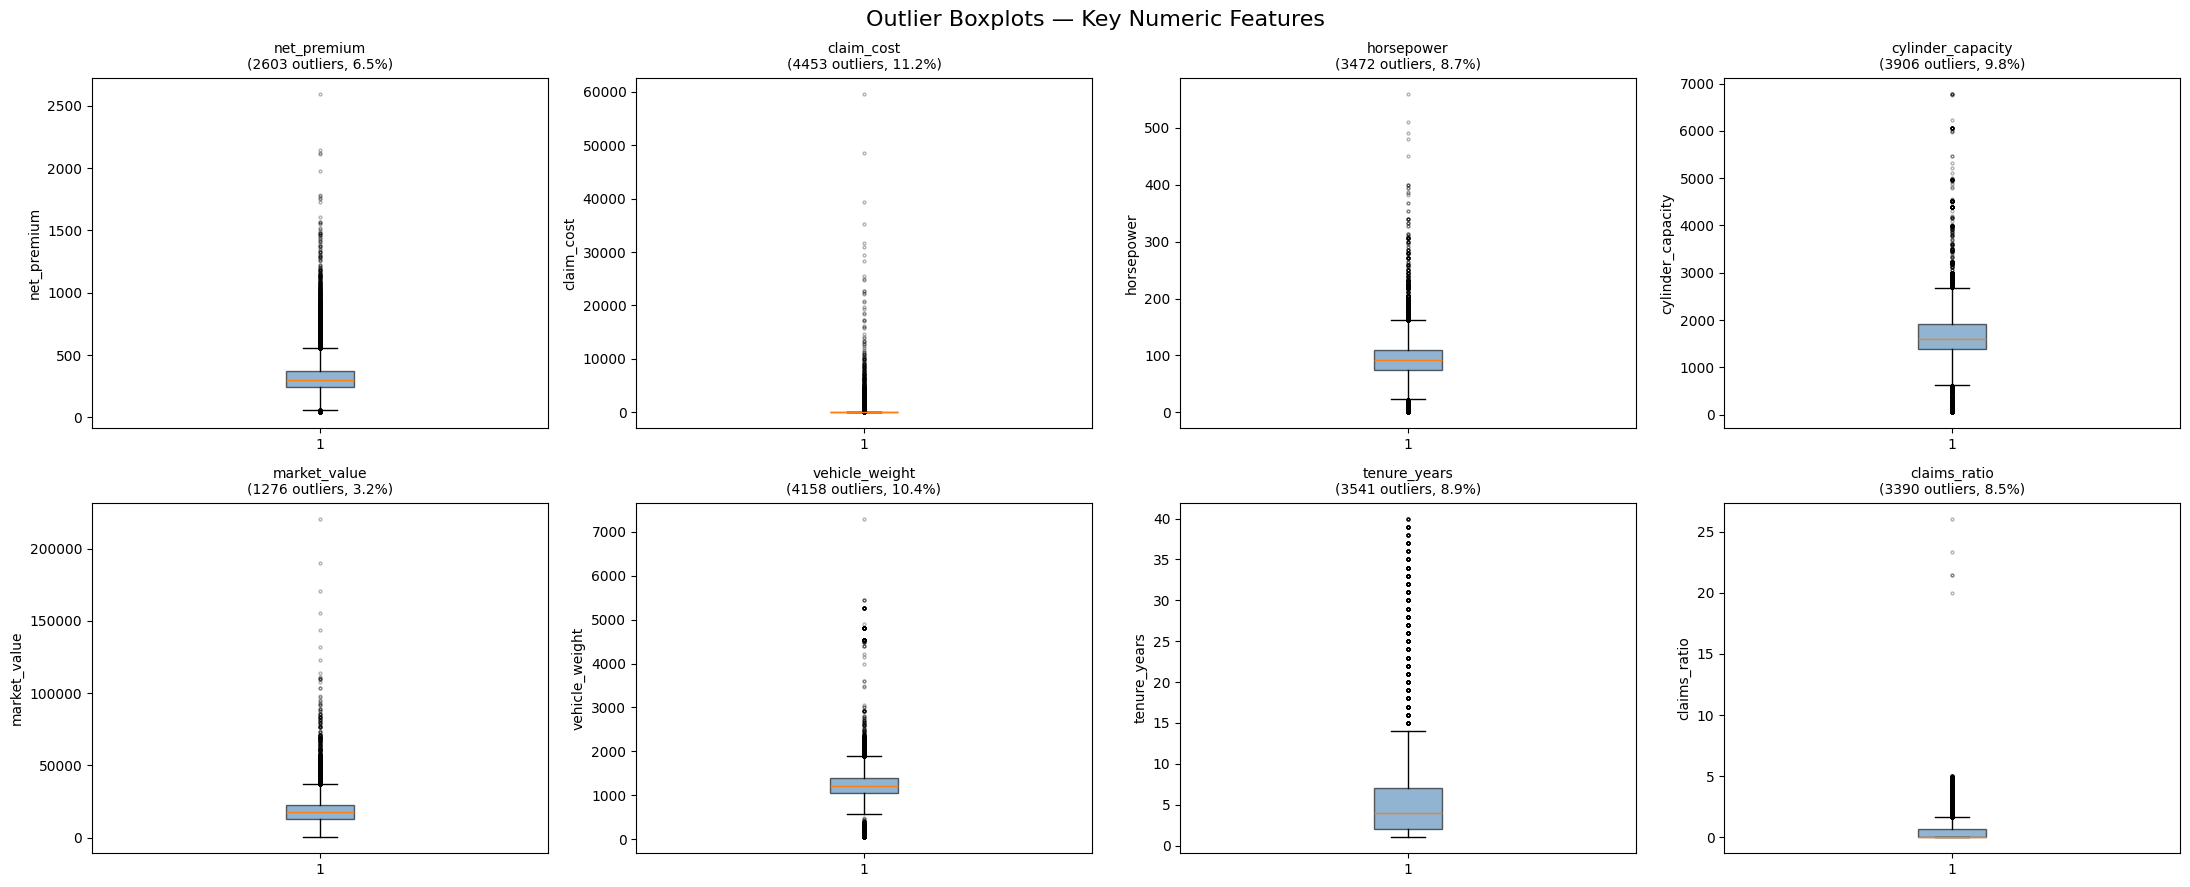

In [13]:
# boxplot
plot_features = [
    'net_premium', 'claim_cost', 'horsepower', 'cylinder_capacity',
    'market_value', 'vehicle_weight', 'tenure_years', 'claims_ratio',
]

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Outlier Boxplots — Key Numeric Features', fontsize=16)

for i, col in enumerate(plot_features):
    ax = axes[i // 4, i % 4]
    data = train[col].dropna()
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    ax.set_title(f'{col}\n({n_out} outliers, {n_out/len(data)*100:.1f}%)', fontsize=10)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

### Data Sanity

In [14]:
# negative value check
numeric_check_cols = ['tenure_years', 'num_policies', 'max_policies_ever',
                      'max_products_simul', 'policies_canceled', 'net_premium',
                      'claim_cost', 'num_claims', 'total_claims_history',
                      'horsepower', 'cylinder_capacity', 'market_value', 'vehicle_weight']
neg_issues = {c: (train[c] < 0).sum() for c in numeric_check_cols if (train[c] < 0).sum() > 0}
print(f"Negative values in positive-only columns")
print(f"  Issues: {neg_issues if neg_issues else 'None'}")

Negative values in positive-only columns
  Issues: None


In [15]:
# convert all date columns to datetime
date_cols = ['contract_start_date', 'last_renewal_date', 'next_renewal_date',
             'birth_date', 'license_date']
for col in date_cols:
    train[col] = pd.to_datetime(train[col], format='%d/%m/%Y')
    test[col] = pd.to_datetime(test[col], format='%d/%m/%Y')

print("Date Ranges (Train)")
for col in date_cols:
    print(f"  {col}: {train[col].min().date()} to {train[col].max().date()}")

# date consistency checks
print("\nDate Consistency")
n_bad = (train['contract_start_date'] > train['last_renewal_date']).sum()
print(f"  contract_start > last_renewal: {n_bad} rows")
# These 35 rows have contract start after renewal — likely multi-year policies
# that renewed before the original start date passed. Keep them; the derived
# tenure feature will handle this.

print(f"  last_renewal >= next_renewal: "
      f"{(train['last_renewal_date'] >= train['next_renewal_date']).sum()} rows")

print(f"  born after getting license: "
      f"{(train['birth_date'] > train['license_date']).sum()} rows")

# Contract duration
contract_dur = (train['next_renewal_date'] - train['last_renewal_date']).dt.days
print(f"  Contract duration (next - last renewal): min={contract_dur.min()}, "
      f"max={contract_dur.max()} days")



Date Ranges (Train)
  contract_start_date: 1980-10-25 to 2018-11-30
  last_renewal_date: 2015-11-02 to 2018-11-30
  next_renewal_date: 2016-11-02 to 2019-11-30
  birth_date: 1918-04-05 to 2000-10-11
  license_date: 1942-10-01 to 2018-11-26

Date Consistency
  contract_start > last_renewal: 35 rows
  last_renewal >= next_renewal: 0 rows
  born after getting license: 0 rows
  Contract duration (next - last renewal): min=365, max=366 days


There are 35 rows having contract start after renewal, likely multi-year policies that renewed before the original start date passed.

In [16]:
# age range
age_at_license = (train['license_date'] - train['birth_date']).dt.days / 365
age_at_renewal = (train['last_renewal_date'] - train['birth_date']).dt.days / 365
print(f"Age Checks")
print(f"  Age at license: min={age_at_license.min():.1f}, max={age_at_license.max():.1f}")
print(f"  Age at renewal: min={age_at_renewal.min():.1f}, max={age_at_renewal.max():.1f}")

Age Checks
  Age at license: min=18.0, max=72.9
  Age at renewal: min=18.1, max=98.6


In [17]:
mask_hp0 = train['horsepower'] == 0
mask_fuel_na = train['fuel_type'].isnull()
print(f"  horsepower == 0: {mask_hp0.sum()}")
print(f"  fuel_type is NaN: {mask_fuel_na.sum()}")
print(f"  Both: {(mask_hp0 & mask_fuel_na).sum()}")
print(f"  vehicle type: "
      f"{train.loc[mask_hp0, 'risk_type'].value_counts().to_dict()}")

  horsepower == 0: 453
  fuel_type is NaN: 453
  Both: 453
  vehicle type: {1: 431, 4: 22}


The 453 missing records of fuel_type are belong to records of motorbikes and agricultural vehicles. We will address them in the feature engineering part.

In [18]:
print(f"num_doors == 0")
print(f"  Count: {(train['num_doors'] == 0).sum()}")
print(f"  risk_type breakdown: "
      f"{train.loc[train['num_doors']==0, 'risk_type'].value_counts().to_dict()}")
# Consistent: motorbikes & agri vehicles have 0 doors

# check if num_claims>0 but claims_ratio==0
problem_halc = (train['num_claims'] > 0) & (train['claims_ratio'] == 0)
print(f"\nnum_claims>0 but claims_ratio=0")
print(f"  Count: {problem_halc.sum()}")
# HALC = LC * claims_ratio = LC * 0 = 0 for these rows, so no special handling needed

num_doors == 0
  Count: 3246
  risk_type breakdown: {1: 3014, 4: 232}

num_claims>0 but claims_ratio=0
  Count: 15


## Construct Target Variables and checks for imbalance

In [19]:
# LC: Loss Cost per Exposure Unit
train['LC'] = np.where(train['num_claims'] > 0, train['claim_cost'] / train['num_claims'], 0.0)

# Historically Adjusted Loss Cost: HALC = LC * claims_ratio
train['HALC'] = np.where(train['num_claims'] > 0,
    (train['claim_cost'] / train['num_claims']) * train['claims_ratio'],
    0.0)

# Claim Status (binary)
train['CS'] = (train['num_claims'] > 0).astype(int)

In [20]:
print(f"LC  — non-zero: {(train['LC']>0).sum()}/{len(train)} "
      f"({(train['LC']>0).mean()*100:.1f}%)")
print(f"mean(all)={train['LC'].mean():.2f}, "
      f"mean(non-zero)={train.loc[train['LC']>0, 'LC'].mean():.2f}, "
      f"median(non-zero)={train.loc[train['LC']>0, 'LC'].median():.2f}")

print(f"\nHALC — non-zero: {(train['HALC']>0).sum()}/{len(train)} "
      f"({(train['HALC']>0).mean()*100:.1f}%)")
print(f"mean(all)={train['HALC'].mean():.2f}, "
      f"mean(non-zero)={train.loc[train['HALC']>0, 'HALC'].mean():.2f}")

print(f"\nCS   — 0: {(train['CS']==0).sum()} ({(train['CS']==0).mean()*100:.1f}%), "
      f"1: {(train['CS']==1).sum()} ({(train['CS']==1).mean()*100:.1f}%)")

LC  — non-zero: 4453/39928 (11.2%)
mean(all)=63.93, mean(non-zero)=573.25, median(non-zero)=181.71

HALC — non-zero: 4438/39928 (11.1%)
mean(all)=116.11, mean(non-zero)=1044.59

CS   — 0: 35475 (88.8%), 1: 4453 (11.2%)


## FEATURE ENGINEERING

Missing fuel_type occurs only for motorbikes (risk_type=1) and agricultural vehicles (risk_type=4) that also have horsepower=0. Among recorded values: motorbikes are 99.5% Petrol, agri are 97.5% Diesel.Therefore we will impute with the dominant fuel type per risk_type, then encode.

**14 new features were created** including age, driving experience, vehicle age, vehicle value per kg, premium per unit of vehicle value, power-to-weight ratio, renewal month and quarter, and fuel/risk type encodings.

In [21]:
def engineer_features(df):
  # Age of insured at last renewal
  df['age'] = (df['last_renewal_date'] - df['birth_date']).dt.days / 365

  # Driving experience (years since license at last renewal)
  df['driving_exp'] = (df['last_renewal_date'] - df['license_date']).dt.days / 365

  # Vehicle age at last renewal
  df['vehicle_age'] = df['last_renewal_date'].dt.year - df['vehicle_reg_year']

  # Age when got license
  df['age_at_license'] = (df['license_date'] - df['birth_date']).dt.days / 365.25

  # Power-to-weight ratio
  df['power_to_weight'] = np.where(df['vehicle_weight'] > 0, df['horsepower'] / df['vehicle_weight'],0)

  # Vehicle value per kg
  df['value_per_kg'] = np.where(df['vehicle_weight'] > 0, df['market_value'] / df['vehicle_weight'],0)

  # Premium per unit of vehicle value
  df['premium_to_value'] = np.where(df['market_value'] > 0, df['net_premium'] / df['market_value'], 0)

  # risk_type as dummies ---
  # 1=motorbike, 2=van, 3=passenger car, 4=agricultural
  df['risk_motorbike'] = (df['risk_type'] == 1).astype(int)
  df['risk_van'] = (df['risk_type'] == 2).astype(int)
  df['risk_car'] = (df['risk_type'] == 3).astype(int)
  df['risk_agri'] = (df['risk_type'] == 4).astype(int)

  # renewal month and quarter (can be used for checking seasonality)
  df['renewal_month'] = df['last_renewal_date'].dt.month
  df['renewal_quarter'] = df['last_renewal_date'].dt.quarter

  # impute fuel type
  df.loc[df['fuel_type'].isnull() & (df['risk_type'] == 1), 'fuel_type'] = 'P'
  df.loc[df['fuel_type'].isnull() & (df['risk_type'] == 4), 'fuel_type'] = 'D'
  df['fuel_diesel'] = (df['fuel_type'] == 'D').astype(int) # 1 = Diesel, 0 = Petrol

  return df


In [22]:
# Apply feature engineering to both datasets
train = engineer_features(train)
test = engineer_features(test)

# Identify original vs engineered columns
ORIGINAL_COLS = list(rename_map.values())
print("New features created:")
new_cols = [c for c in train.columns if c not in ORIGINAL_COLS + ['LC', 'HALC', 'CS']]
for c in new_cols:
    print(f"{c}: min={train[c].min():.2f}, max={train[c].max():.2f}, "
          f"mean={train[c].mean():.2f}")

New features created:
age: min=18.13, max=98.60, mean=47.26
driving_exp: min=-0.47, max=74.08, mean=24.58
vehicle_age: min=0.00, max=68.00, mean=12.64
age_at_license: min=18.00, max=72.80, mean=22.66
power_to_weight: min=0.00, max=2.52, mean=0.08
value_per_kg: min=0.33, max=138.15, mean=16.16
premium_to_value: min=0.00, max=0.75, mean=0.02
risk_motorbike: min=0.00, max=1.00, mean=0.08
risk_van: min=0.00, max=1.00, mean=0.12
risk_car: min=0.00, max=1.00, mean=0.79
risk_agri: min=0.00, max=1.00, mean=0.01
renewal_month: min=1.00, max=12.00, mean=6.61
renewal_quarter: min=1.00, max=4.00, mean=2.54
fuel_diesel: min=0.00, max=1.00, mean=0.62


## EDA

### Key visual findings:

1. **Target distributions**: LC and HALC exhibit extreme right skew
even after removing zeros. The targets are heavily zero-inflated (88.8% zeros), confirming the Tweedie distribution approach mentioned in the project instructions. The class imbalance for CS is roughly 89:11. Log transformation produces a roughly normal shape for non-zero LC.
2. **Claim rates by category** : Vans (risk_type = 2) show the highest claim rate (15%), followed by passenger cars (10%), while motorbikes have the lowest (4%). Half-yearly payment (payment_method = 1) is associated with higher claim rates (16%) than annual payment (7%). Urban policyholders claim slightly more often than rural ones.
3. **Age and claim rate** : Claim rates are relatively flat across insured ages 25–75 (around 10–12%) with a dip for the youngest (<25) and oldest (>80) age groups. Vehicle age shows a gradual increase in claim rate from ~8% for newer vehicles to ~14% for vehicles aged 20–30 years, followed by a decline for very old vehicles (likely low-mileage classic vehicles).
4. **Correlation structure** : The vehicle specification cluster (horsepower, cylinder_capacity, market_value, vehicle_weight) forms a tightly correlated group, suggesting these variables capture a single underlying "vehicle size/value" dimension.

### Target distributions

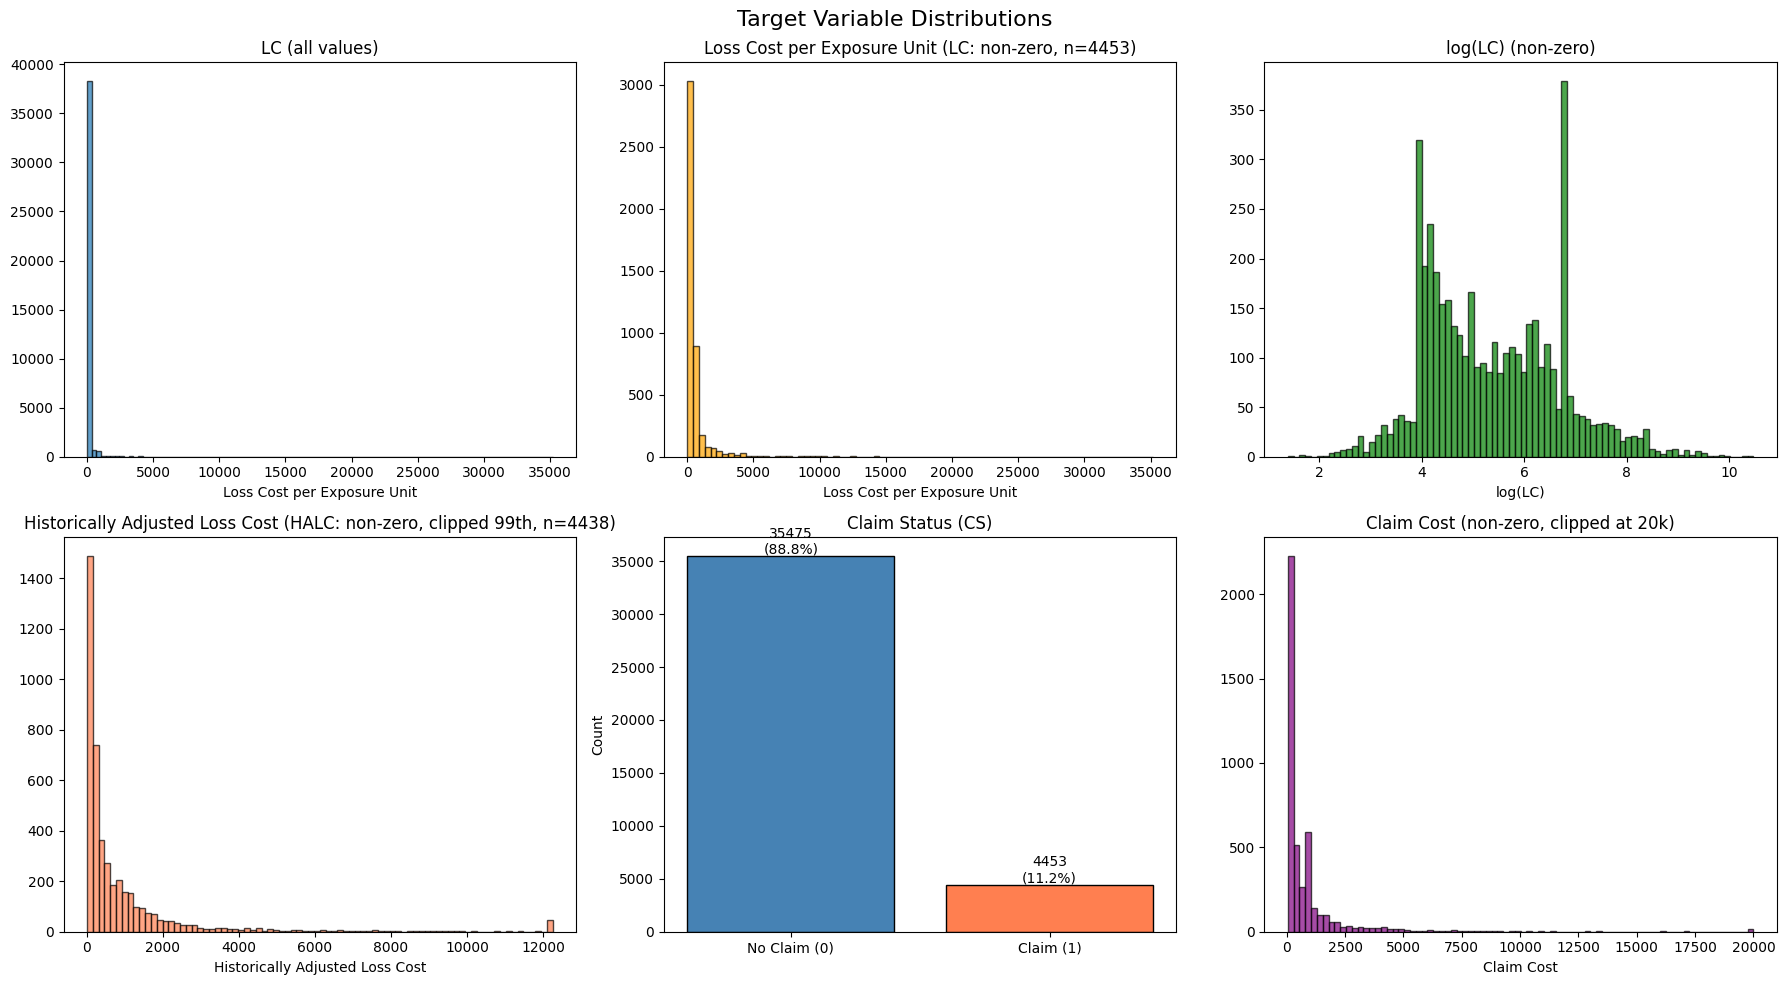

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Target Variable Distributions', fontsize=16)

# LC distribution (all)
axes[0, 0].hist(train['LC'], bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('LC (all values)')
axes[0, 0].set_xlabel('Loss Cost per Exposure Unit')

# LC distribution (non-zero only)
lc_nz = train.loc[train['LC'] > 0, 'LC']
axes[0, 1].hist(lc_nz, bins=80, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title(f'Loss Cost per Exposure Unit (LC: non-zero, n={len(lc_nz)})')
axes[0, 1].set_xlabel('Loss Cost per Exposure Unit')

# Log LC (non-zero)
axes[0, 2].hist(np.log(lc_nz), bins=80, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_title('log(LC) (non-zero)')
axes[0, 2].set_xlabel('log(LC)')

# HALC distribution (non-zero only)
halc_nz = train.loc[train['HALC'] > 0, 'HALC']
axes[1, 0].hist(halc_nz.clip(upper=halc_nz.quantile(0.99)), bins=80,
                edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_title(f'Historically Adjusted Loss Cost (HALC: non-zero, clipped 99th, n={len(halc_nz)})')
axes[1, 0].set_xlabel('Historically Adjusted Loss Cost')

# CS distribution
cs_counts = train['CS'].value_counts().sort_index()
axes[1, 1].bar(['No Claim (0)', 'Claim (1)'], cs_counts.values,
               color=['steelblue', 'coral'], edgecolor='black')
axes[1, 1].set_title('Claim Status (CS)')
axes[1, 1].set_ylabel('Count')
for i, v in enumerate(cs_counts.values):
    axes[1, 1].text(i, v + 200, f'{v}\n({v/len(train)*100:.1f}%)', ha='center')

# Raw claim cost
axes[1, 2].hist(train.loc[train['claim_cost'] > 0, 'claim_cost'].clip(upper=20000),
                bins=80, edgecolor='black', alpha=0.7, color='purple')
axes[1, 2].set_title('Claim Cost (non-zero, clipped at 20k)')
axes[1, 2].set_xlabel('Claim Cost')

plt.tight_layout()
plt.show()

### Feature distributions for key numeric variables

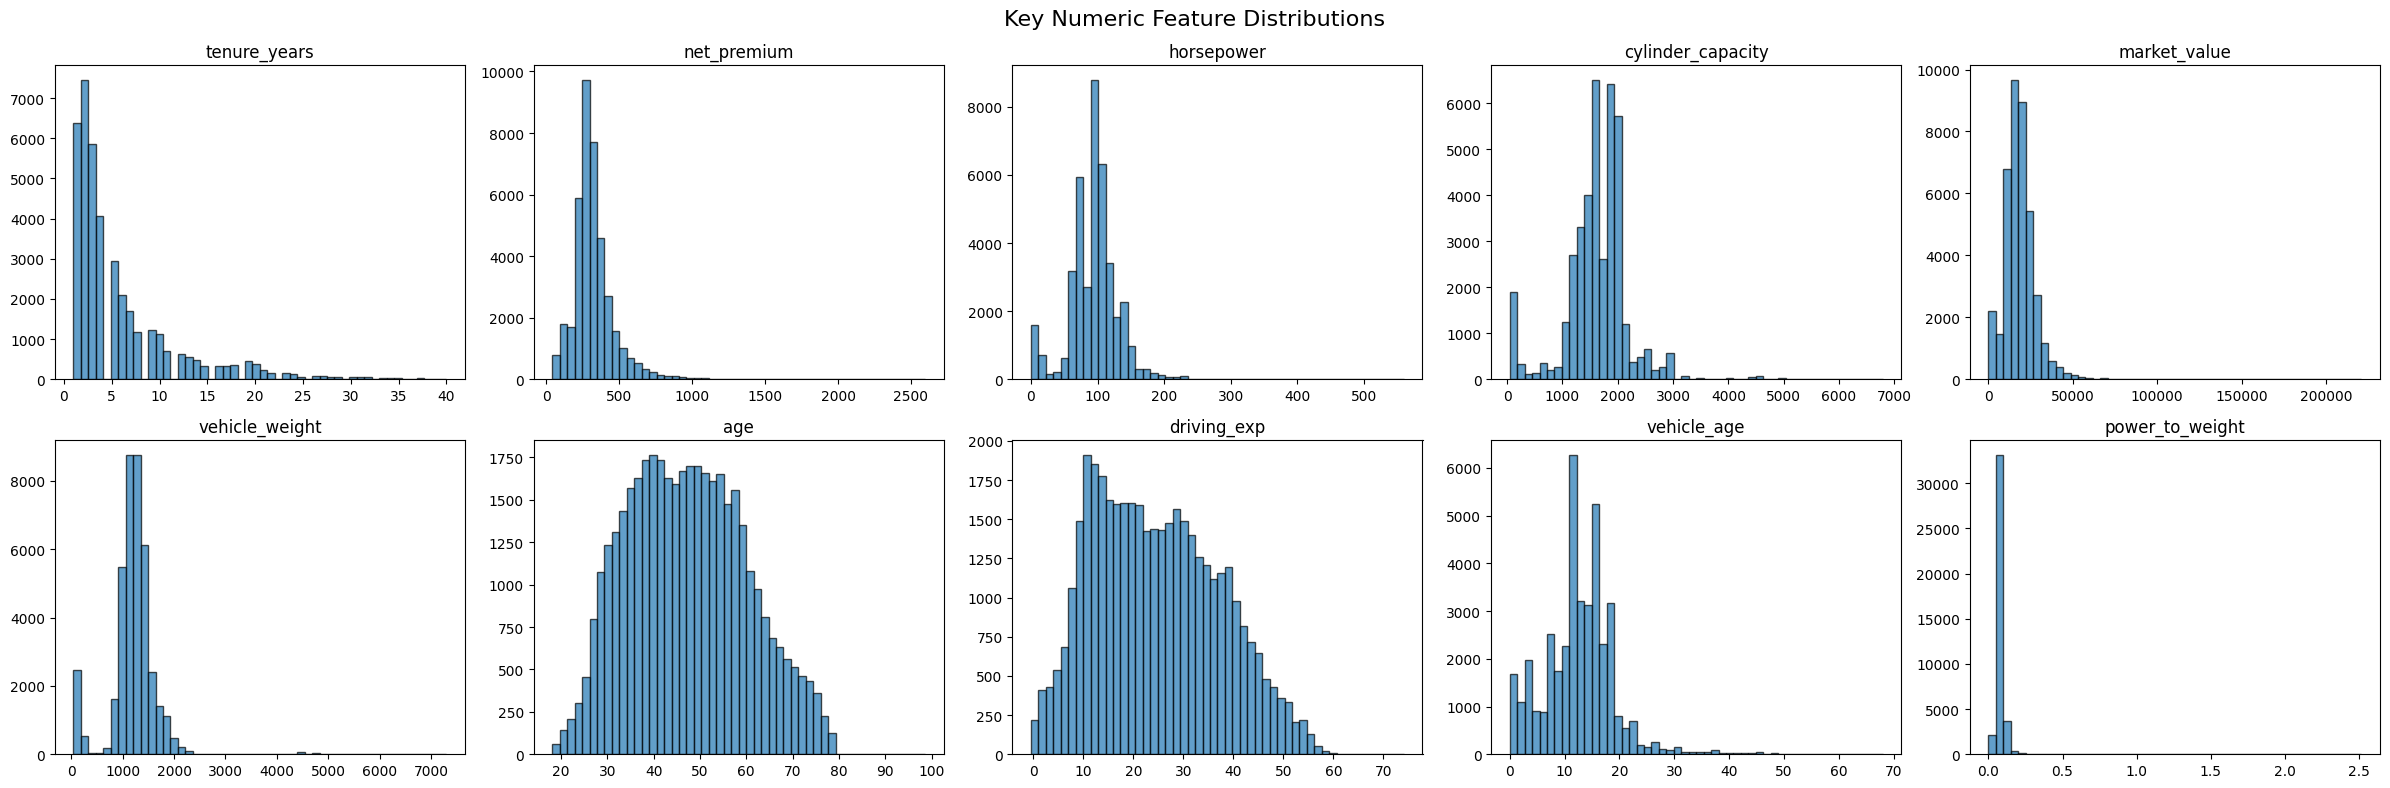

In [24]:
num_features = ['tenure_years', 'net_premium', 'horsepower', 'cylinder_capacity',
                'market_value', 'vehicle_weight',
                'age', 'driving_exp', 'vehicle_age', 'power_to_weight']

fig, axes = plt.subplots(2, 5, figsize=(24, 8))
fig.suptitle('Key Numeric Feature Distributions', fontsize=16)
for i, col in enumerate(num_features):
    ax = axes[i // 5, i % 5]
    ax.hist(train[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

### Categorical feature distributions vs claim status

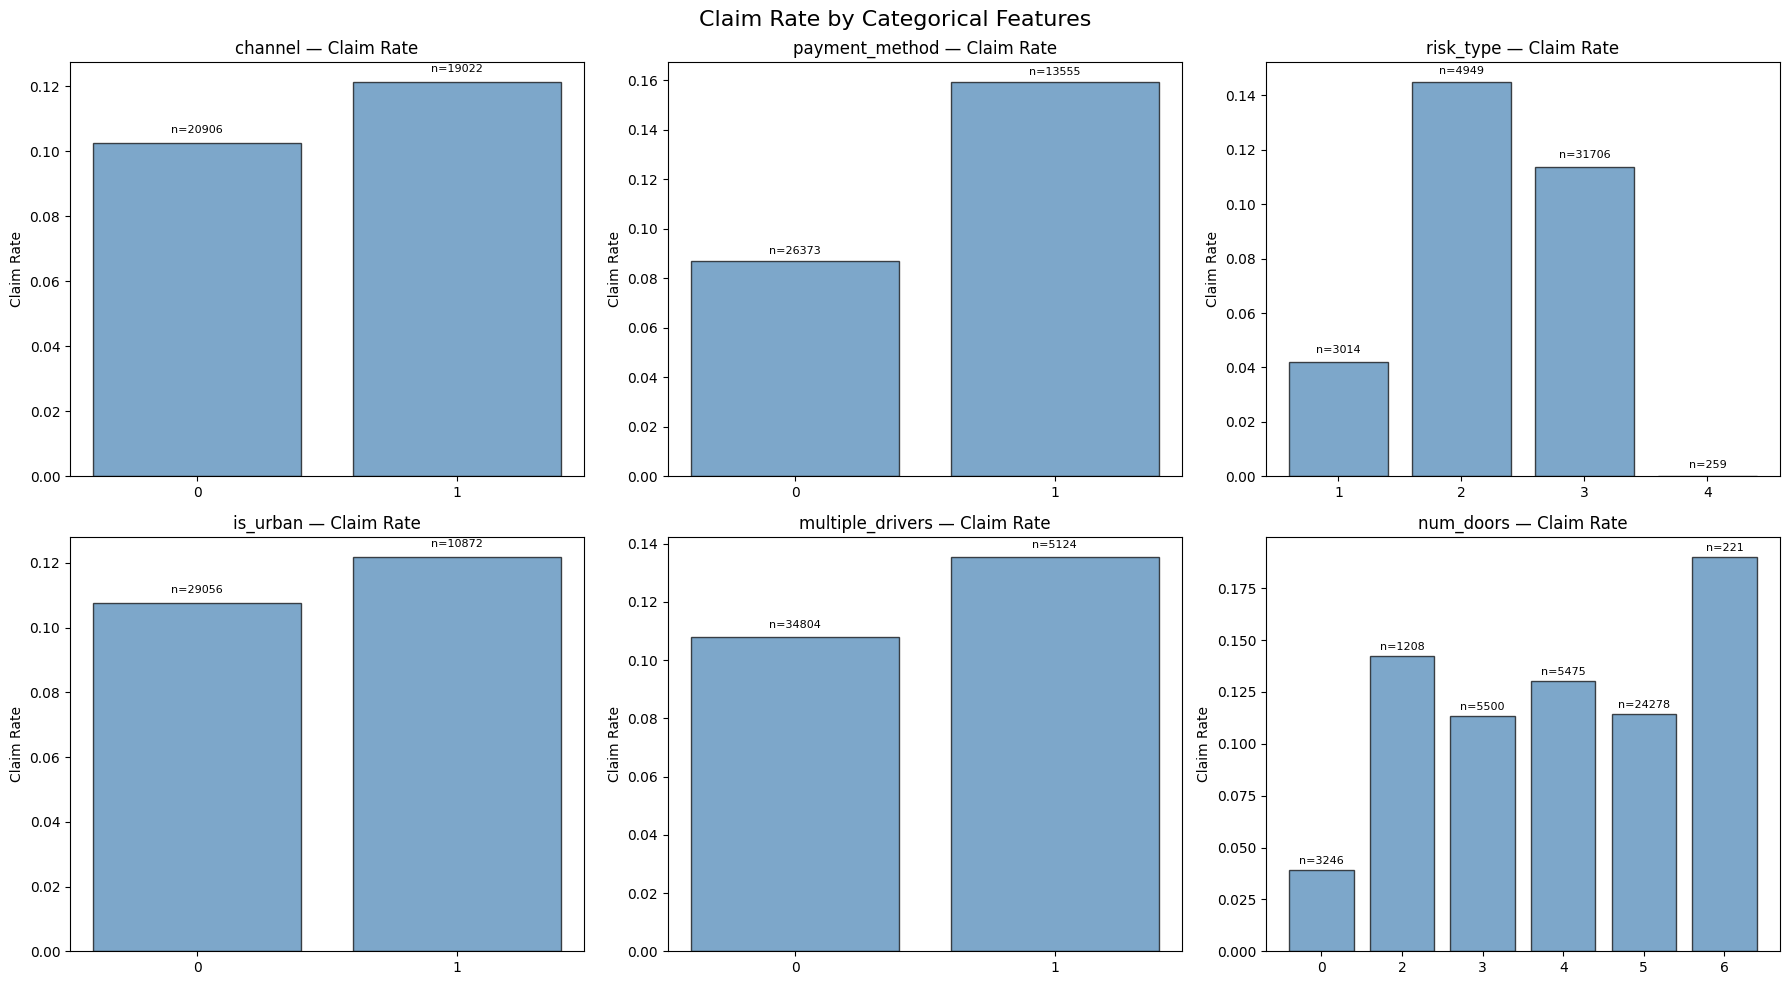

In [25]:
cat_features = ['channel', 'payment_method', 'risk_type', 'is_urban',
                'multiple_drivers', 'num_doors']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Claim Rate by Categorical Features', fontsize=16)
for i, col in enumerate(cat_features):
    ax = axes[i // 3, i % 3]
    claim_rate = train.groupby(col)['CS'].mean()
    counts = train[col].value_counts().sort_index()
    bars = ax.bar(claim_rate.index.astype(str), claim_rate.values,color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col} — Claim Rate')
    ax.set_ylabel('Claim Rate')
    # Add count labels
    for j, (idx, val) in enumerate(claim_rate.items()):
        ax.text(j, val + 0.003, f'n={counts[idx]}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### Correlation heatmap of numeric features

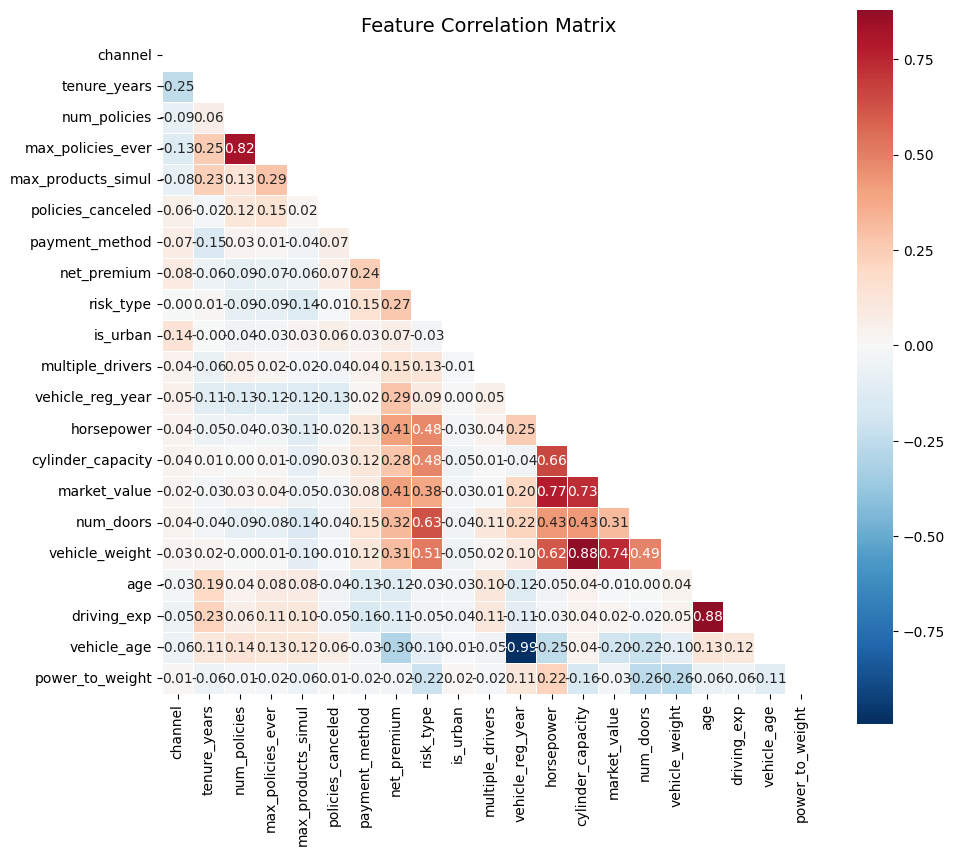

In [26]:
corr_cols = ['channel', 'tenure_years', 'num_policies', 'max_policies_ever',
             'max_products_simul', 'policies_canceled', 'payment_method', 'net_premium',
             'risk_type', 'is_urban', 'multiple_drivers', 'vehicle_reg_year',
             'horsepower', 'cylinder_capacity', 'market_value', 'num_doors',
             'vehicle_weight', 'age', 'driving_exp', 'vehicle_age', 'power_to_weight']

fig, ax = plt.subplots(figsize=(10, 10))
corr_matrix = train[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

### Claim rate by age bins and vehicle age

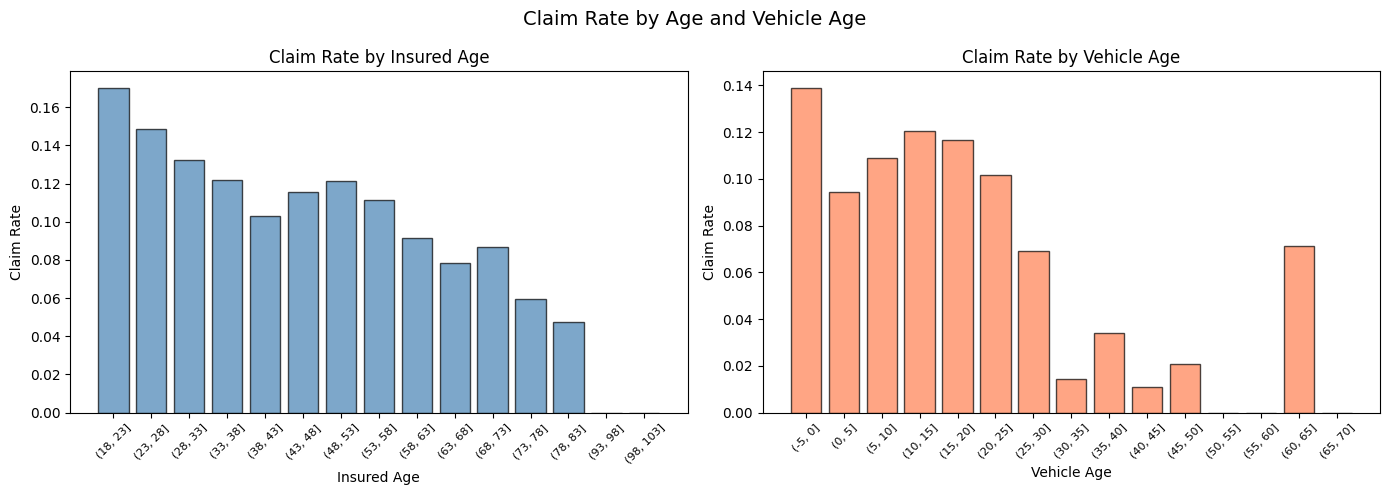

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Claim Rate by Age and Vehicle Age', fontsize=14)

# By insured age
train['age_bin'] = pd.cut(train['age'], bins=range(18, 105, 5))
age_claim = train.groupby('age_bin', observed=True)['CS'].agg(['mean', 'count'])
axes[0].bar(range(len(age_claim)), age_claim['mean'], color='steelblue',
            edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(len(age_claim)))
axes[0].set_xticklabels([str(x) for x in age_claim.index], rotation=45, fontsize=8)
axes[0].set_title('Claim Rate by Insured Age')
axes[0].set_ylabel('Claim Rate')
axes[0].set_xlabel('Insured Age')

# By vehicle age
train['veh_age_bin'] = pd.cut(train['vehicle_age'], bins=range(-5, 75, 5))
veh_claim = train.groupby('veh_age_bin', observed=True)['CS'].agg(['mean', 'count'])
axes[1].bar(range(len(veh_claim)), veh_claim['mean'], color='coral',
            edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(veh_claim)))
axes[1].set_xticklabels([str(x) for x in veh_claim.index], rotation=45, fontsize=8)
axes[1].set_title('Claim Rate by Vehicle Age')
axes[1].set_ylabel('Claim Rate')
axes[1].set_xlabel('Vehicle Age')

plt.tight_layout()
plt.show()

# Drop temporary binning columns
train.drop(columns=['age_bin', 'veh_age_bin'], inplace=True)

### LC and HALC vs key features

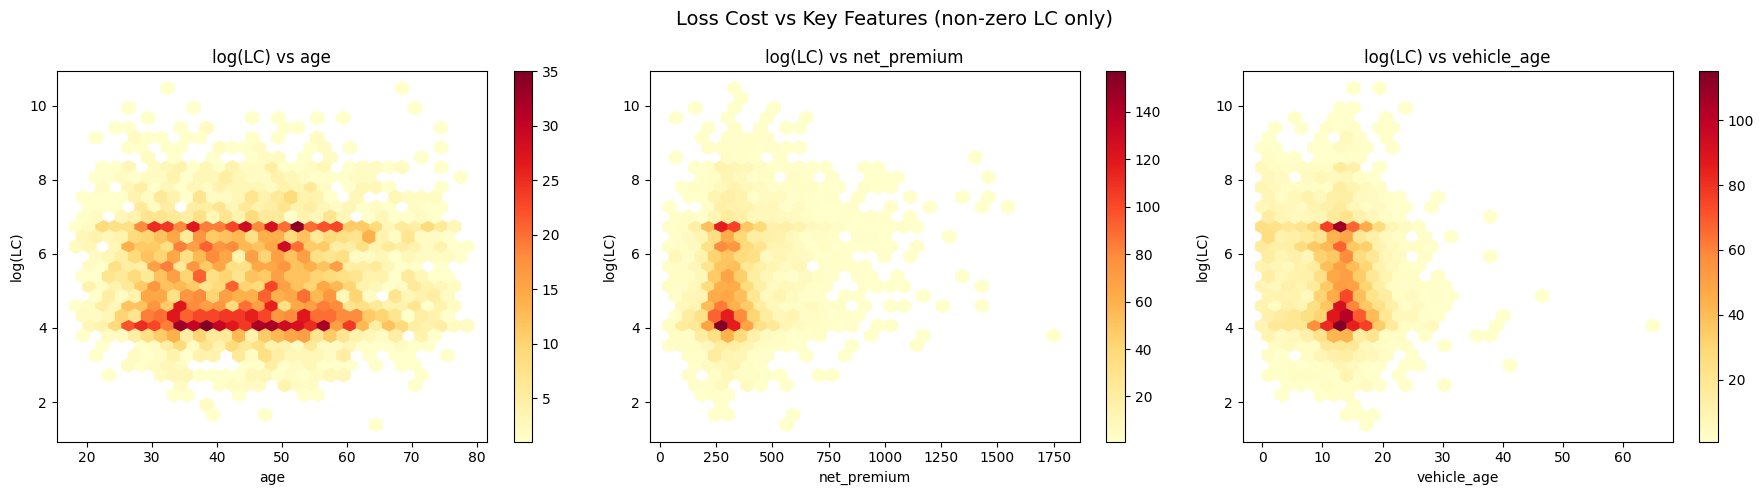

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Loss Cost vs Key Features (non-zero LC only)', fontsize=14)
nz = train[train['LC'] > 0]

for i, col in enumerate(['age', 'net_premium', 'vehicle_age']):
    axes[i].hexbin(nz[col], np.log(nz['LC']), gridsize=30, cmap='YlOrRd', mincnt=1)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log(LC)')
    axes[i].set_title(f'log(LC) vs {col}')
    plt.colorbar(axes[i].collections[0], ax=axes[i])

plt.tight_layout()
plt.show()


## Next Steps

Pick variables into feature columns, then create X_train, X_test, y_train for predicting modeling. We won't have y_test since the professor holds the true test labels and will evaluate our predictions against them.

e.g.



```
feature_cols = [] # pick your variables here

X_train = train[feature_cols].copy()
y_train_LC = train['LC'].copy()
y_train_HALC = train['HALC'].copy()
y_train_CS = train['CS'].copy()

X_test = test[feature_cols].copy()

targets = pd.DataFrame({
    'LC': y_train_LC,
    'HALC': y_train_HALC,
    'CS': y_train_CS
})

# Save to CSV
X_train.to_csv('X_train_clean.csv', index=False)
X_test.to_csv('X_test_clean.csv', index=False)
targets.to_csv('y_train_targets.csv', index=False)

```

### Suggested columns dropped from modeling:

**contract_id**: identifier, not a predictor

**contract_start_date, last_renewal_date, next_renewal_date, birth_date, license_date:** raw dates replaced by derived features (age, driving_exp, vehicle_age, etc.)

**claim_cost, num_claims, total_claims_history, claims_ratio**: target-related, unavailable in test set

**fuel_type**: replaced by fuel_diesel encoding



In [29]:
# Drop problematic columns
# The original column names 'X.1', 'X.15', 'X.16', 'X.17', 'X.18' have been renamed.
# Using the new descriptive names as per the `rename_map`.
drop_cols = ['contract_id', 'claim_cost', 'num_claims', 'total_claims_history', 'claims_ratio',
             'contract_start_date', 'last_renewal_date', 'next_renewal_date', 'birth_date', 'license_date',
             'fuel_type', 'risk_type',
             'LC', 'HALC', 'CS']

# Use 'train' instead of 'train_df'
X = train.drop(columns=drop_cols)

# Targets
# Use 'train' instead of 'train_df' and renamed columns in calculations.


y_LC = train['LC']
y_HALC = train['HALC']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_LC_train, y_LC_val = train_test_split(X, y_LC, test_size=0.2, random_state=42)
_, _, y_HALC_train, y_HALC_val = train_test_split(X, y_HALC, test_size=0.2, random_state=42)

In [31]:
import lightgbm as lgb

lgb_model_LC = lgb.LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.5,
    learning_rate=0.05,
    n_estimators=400,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model_LC.fit(X_train, y_LC_train)

# HALC model (separate model)
lgb_model_HALC = lgb.LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.5,
    learning_rate=0.05,
    n_estimators=400,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model_HALC.fit(X_train, y_HALC_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009069 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2983
[LightGBM] [Info] Number of data points in the train set: 31942, number of used features: 30
[LightGBM] [Info] Start training from score 4.151873
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013771 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2983
[LightGBM] [Info] Number of data points in the train set: 31942, number of used features: 30
[LightGBM] [Info] Start training from score 4.745304


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=400,
              objective='tweedie', random_state=42, subsample=0.8,
              tweedie_variance_power=1.5)

In [32]:
from xgboost import XGBRegressor

xgb_model_LC = XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    learning_rate=0.05,
    max_depth=6,
    n_estimators=400,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_LC.fit(X_train, y_LC_train)

# HALC model
xgb_model_HALC = XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    learning_rate=0.05,
    max_depth=6,
    n_estimators=400,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_HALC.fit(X_train, y_HALC_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [33]:
from sklearn.metrics import mean_squared_error

# LightGBM
lgb_LC_preds = lgb_model_LC.predict(X_val)
lgb_HALC_preds = lgb_model_HALC.predict(X_val)

# XGBoost
xgb_LC_preds = xgb_model_LC.predict(X_val)
xgb_HALC_preds = xgb_model_HALC.predict(X_val)

print("LightGBM LC MSE:", mean_squared_error(y_LC_val, lgb_LC_preds))
print("LightGBM HALC MSE:", mean_squared_error(y_HALC_val, lgb_HALC_preds))

print("XGBoost LC MSE:", mean_squared_error(y_LC_val, xgb_LC_preds))
print("XGBoost HALC MSE:", mean_squared_error(y_HALC_val, xgb_HALC_preds))

LightGBM LC MSE: 260083.14508735604
LightGBM HALC MSE: 1024629.3854445494
XGBoost LC MSE: 261269.81105673907
XGBoost HALC MSE: 1030391.869110623


In [60]:
X_test = test.copy()
# Drop the same problematic columns from X_test as were dropped from the training data X
X_test = X_test.drop(columns=drop_cols, errors='ignore')

assert list(X_test.columns) == list(X.columns), \
    f"Column mismatch!\nTrain: {list(X.columns)}\nTest: {list(X_test.columns)}"

LC_pred = lgb_model_LC.predict(X_test)
HALC_pred = lgb_model_HALC.predict(X_test)

AssertionError: Column mismatch!
Train: ['channel', 'tenure_years', 'num_policies', 'max_policies_ever', 'max_products_simul', 'policies_canceled', 'payment_method', 'net_premium', 'is_urban', 'multiple_drivers', 'vehicle_reg_year', 'horsepower', 'cylinder_capacity', 'market_value', 'num_doors', 'vehicle_weight', 'age', 'driving_exp', 'vehicle_age', 'age_at_license', 'power_to_weight', 'value_per_kg', 'premium_to_value', 'risk_motorbike', 'risk_van', 'risk_car', 'risk_agri', 'renewal_month', 'renewal_quarter', 'fuel_diesel']
Test: ['contract_start_date', 'last_renewal_date', 'next_renewal_date', 'birth_date', 'license_date', 'channel', 'tenure_years', 'num_policies', 'max_policies_ever', 'max_products_simul', 'policies_canceled', 'payment_method', 'net_premium', 'risk_type', 'is_urban', 'multiple_drivers', 'vehicle_reg_year', 'horsepower', 'cylinder_capacity', 'market_value', 'num_doors', 'fuel_type', 'vehicle_weight', 'age', 'driving_exp', 'vehicle_age', 'age_at_license', 'power_to_we

Computing SHAP values for LC winner (LightGBM)...


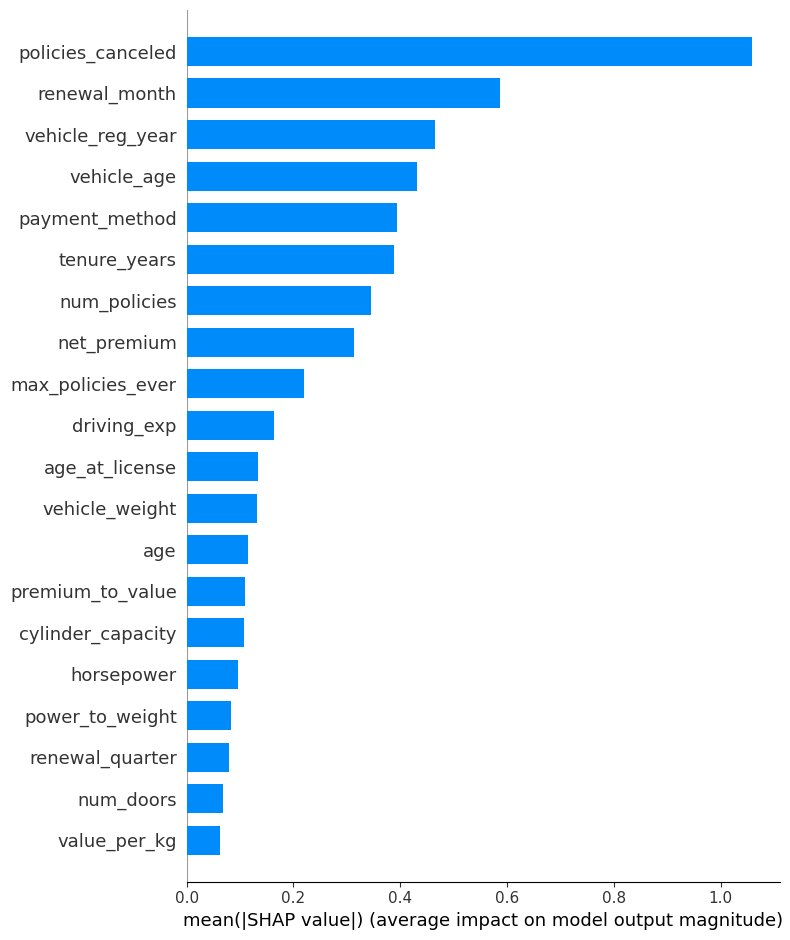

Saved: shap_LC_bar.png


In [35]:
import shap
import matplotlib.pyplot as plt

# Define the winner LC model and its name
# Based on previous MSE results, LightGBM had a slightly lower MSE for LC.
winner_LC = lgb_model_LC
winner_LC_name = 'LightGBM'

print(f'Computing SHAP values for LC winner ({winner_LC_name})...')

explainer_LC = shap.TreeExplainer(winner_LC)
shap_vals_LC = explainer_LC.shap_values(X_train)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_LC, X_train, plot_type='bar', show=False,
                  title=f'SHAP Feature Importance — LC ({winner_LC_name})')
plt.tight_layout()
plt.savefig('shap_LC_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_LC_bar.png')

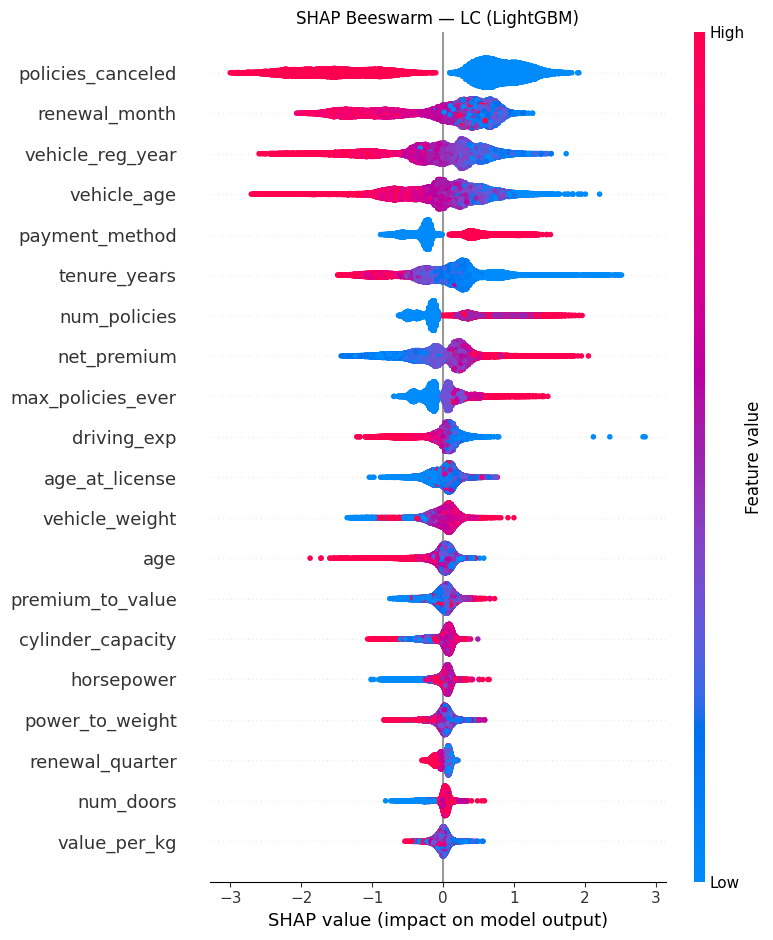

Saved: shap_LC_beeswarm.png


In [36]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_LC, X_train, show=False)
plt.title(f'SHAP Beeswarm — LC ({winner_LC_name})')
plt.tight_layout()
plt.savefig('shap_LC_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_LC_beeswarm.png')

Computing SHAP values for HALC winner (LightGBM)...


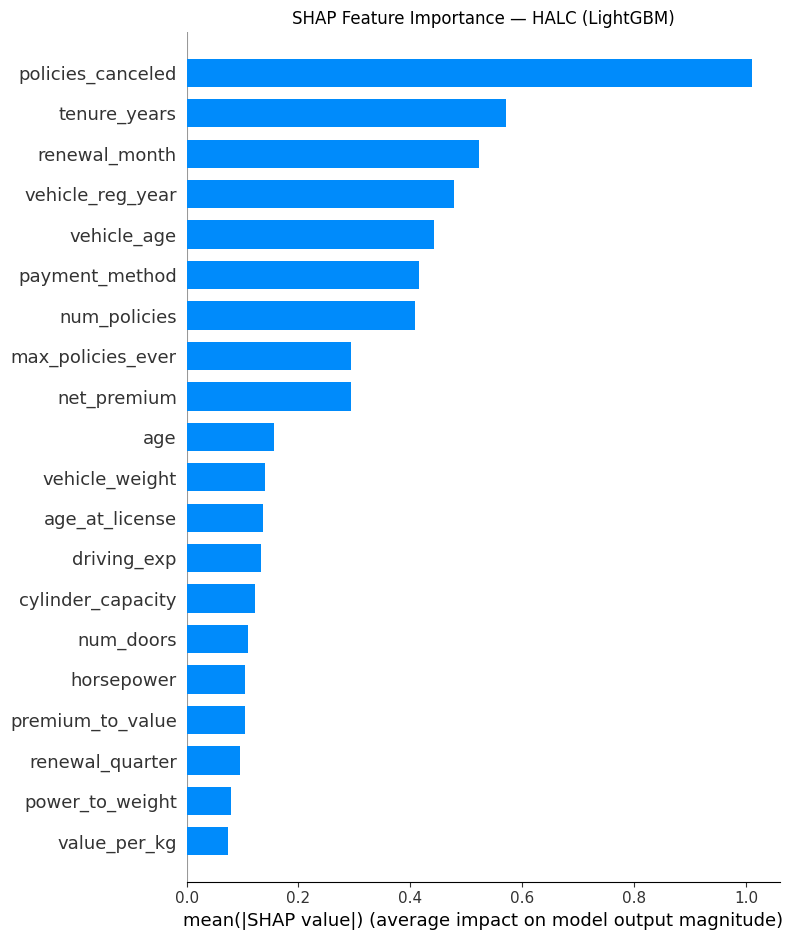

Saved: shap_HALC_bar.png


In [37]:
import shap
import matplotlib.pyplot as plt

# Define the winner HALC model and its name
# Based on previous MSE results, LightGBM had a slightly lower MSE for HALC.
winner_HALC = lgb_model_HALC
winner_HALC_name = 'LightGBM'

print(f'Computing SHAP values for HALC winner ({winner_HALC_name})...')

explainer_HALC = shap.TreeExplainer(winner_HALC)
shap_vals_HALC = explainer_HALC.shap_values(X_train)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_HALC, X_train, plot_type='bar', show=False)
plt.title(f'SHAP Feature Importance — HALC ({winner_HALC_name})')
plt.tight_layout()
plt.savefig('shap_HALC_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_HALC_bar.png')

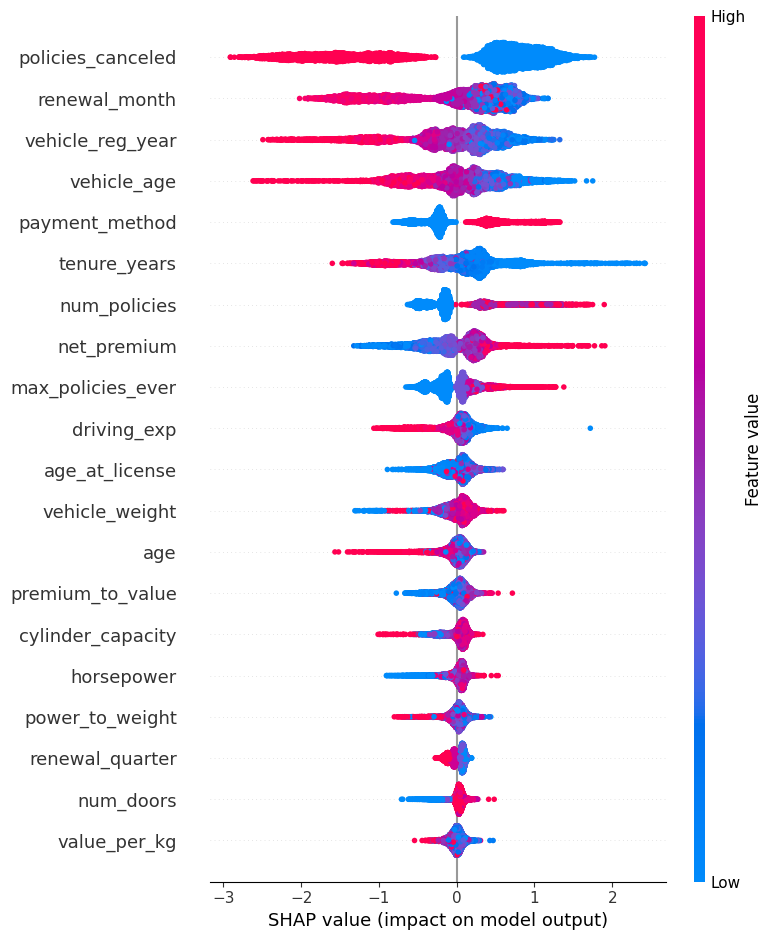

In [38]:
import shap

# Create explainer
explainer = shap.Explainer(lgb_model_LC)

# Compute SHAP values (use a sample if dataset is large)
shap_values = explainer(X_val)

# Summary plot
shap.summary_plot(shap_values, X_val)

##**Random Forest**

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [40]:
rf_model_LC = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model_LC.fit(X_train, y_LC_train)

rf_model_HALC = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

In [41]:
rf_model_HALC.fit(X_train, y_HALC_train)

rf_LC_preds = rf_model_LC.predict(X_val)
rf_HALC_preds = rf_model_HALC.predict(X_val)

print("Random Forest LC MSE:", mean_squared_error(y_LC_val, rf_LC_preds))
print("Random Forest HALC MSE:", mean_squared_error(y_HALC_val, rf_HALC_preds))

Random Forest LC MSE: 261284.6813513405
Random Forest HALC MSE: 1029447.3243063117


##**Two Part**

In [42]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, roc_auc_score


In [43]:
y_LC_train_binary = (y_LC_train > 0).astype(int)
y_LC_val_binary = (y_LC_val > 0).astype(int)

In [44]:
lgb_LC_classifier = lgb.LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    n_estimators=400,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_LC_classifier.fit(X_train, y_LC_train_binary)

LC_prob_positive = lgb_LC_classifier.predict_proba(X_val)[:, 1]

[LightGBM] [Info] Number of positive: 3545, number of negative: 28397
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012652 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2983
[LightGBM] [Info] Number of data points in the train set: 31942, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.110982 -> initscore=-2.080745
[LightGBM] [Info] Start training from score -2.080745


In [45]:
positive_LC_idx = y_LC_train > 0

lgb_LC_positive_regressor = lgb.LGBMRegressor(
    objective="regression",
    learning_rate=0.05,
    n_estimators=400,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_LC_positive_regressor.fit(
    X_train.loc[positive_LC_idx],
    y_LC_train.loc[positive_LC_idx]
)

LC_positive_amount_pred = lgb_LC_positive_regressor.predict(X_val)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2744
[LightGBM] [Info] Number of data points in the train set: 3545, number of used features: 29
[LightGBM] [Info] Start training from score 572.639564


In [46]:
two_part_LC_preds = LC_prob_positive * LC_positive_amount_pred
two_part_LC_preds = np.maximum(two_part_LC_preds, 0)

print("Two-Part LightGBM LC Classifier Accuracy:",
      accuracy_score(y_LC_val_binary, LC_prob_positive >= 0.5))

print("Two-Part LightGBM LC MSE:",
      mean_squared_error(y_LC_val, two_part_LC_preds))

Two-Part LightGBM LC Classifier Accuracy: 0.8893062860005009
Two-Part LightGBM LC MSE: 262744.99833719747


##**HALC**

In [47]:
y_HALC_train_binary = (y_HALC_train > 0).astype(int)
y_HALC_val_binary = (y_HALC_val > 0).astype(int)

In [48]:
lgb_HALC_classifier = lgb.LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    n_estimators=400,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [49]:
lgb_HALC_classifier.fit(X_train, y_HALC_train_binary)

HALC_prob_positive = lgb_HALC_classifier.predict_proba(X_val)[:, 1]

[LightGBM] [Info] Number of positive: 3533, number of negative: 28409
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2983
[LightGBM] [Info] Number of data points in the train set: 31942, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.110607 -> initscore=-2.084559
[LightGBM] [Info] Start training from score -2.084559


In [50]:
positive_HALC_idx = y_HALC_train > 0

lgb_HALC_positive_regressor = lgb.LGBMRegressor(
    objective="regression",
    learning_rate=0.05,
    n_estimators=400,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_HALC_positive_regressor.fit(
    X_train.loc[positive_HALC_idx],
    y_HALC_train.loc[positive_HALC_idx]
)

HALC_positive_amount_pred = lgb_HALC_positive_regressor.predict(X_val)

# Final expected prediction
two_part_HALC_preds = HALC_prob_positive * HALC_positive_amount_pred
two_part_HALC_preds = np.maximum(two_part_HALC_preds, 0)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002025 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2744
[LightGBM] [Info] Number of data points in the train set: 3533, number of used features: 29
[LightGBM] [Info] Start training from score 1040.106386


In [51]:
print("Two-Part LightGBM HALC Classifier Accuracy:",
      accuracy_score(y_HALC_val_binary, HALC_prob_positive >= 0.5))
print("Two-Part LightGBM HALC MSE:",
      mean_squared_error(y_HALC_val, two_part_HALC_preds))

Two-Part LightGBM HALC Classifier Accuracy: 0.890808915602304
Two-Part LightGBM HALC MSE: 1041752.2139878378


In [52]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import numpy as np
import pandas as pd

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def regression_metrics(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

In [53]:
def random_forest_cv(X, y, target_name):
    results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

        rf = RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_tr, y_tr)
        preds = rf.predict(X_va)
        preds = np.maximum(preds, 0)

        metrics = regression_metrics(y_va, preds)
        metrics["Fold"] = fold
        metrics["Target"] = target_name
        metrics["Model"] = "Random Forest"

        results.append(metrics)

    return pd.DataFrame(results)

In [54]:

# Two-Part LightGBM CV Function


def two_part_lgbm_cv(X, y, target_name):
    results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

        y_tr_binary = (y_tr > 0).astype(int)

        # Part 1: Claim occurrence classifier
        clf = lgb.LGBMClassifier(
            objective="binary",
            learning_rate=0.05,
            n_estimators=400,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        clf.fit(X_tr, y_tr_binary)

        prob_positive = clf.predict_proba(X_va)[:, 1]

        # Part 2: Conditional severity regressor
        positive_idx = y_tr > 0

        reg = lgb.LGBMRegressor(
            objective="regression",
            learning_rate=0.05,
            n_estimators=400,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        reg.fit(X_tr.loc[positive_idx], y_tr.loc[positive_idx])

        positive_amount_pred = reg.predict(X_va)

        # Final prediction = probability of nonzero claim * predicted amount
        final_preds = prob_positive * positive_amount_pred
        final_preds = np.maximum(final_preds, 0)

        metrics = regression_metrics(y_va, final_preds)
        metrics["Fold"] = fold
        metrics["Target"] = target_name
        metrics["Model"] = "Two-Part LightGBM"

        results.append(metrics)

    return pd.DataFrame(results)

In [55]:
# ============================================================
# Run CV for LC and HALC
# ============================================================

rf_lc_cv = random_forest_cv(X, y_LC, "LC")
rf_halc_cv = random_forest_cv(X, y_HALC, "HALC")

two_part_lc_cv = two_part_lgbm_cv(X, y_LC, "LC")
two_part_halc_cv = two_part_lgbm_cv(X, y_HALC, "HALC")

cv_results = pd.concat(
    [rf_lc_cv, rf_halc_cv, two_part_lc_cv, two_part_halc_cv],
    ignore_index=True
)

cv_results

[LightGBM] [Info] Number of positive: 3545, number of negative: 28397
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011766 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2983
[LightGBM] [Info] Number of data points in the train set: 31942, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.110982 -> initscore=-2.080745
[LightGBM] [Info] Start training from score -2.080745
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001828 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2744
[LightGBM] [Info] Number of data points in the train set: 3545, number of used features: 29
[LightGBM] [Info] Start training from score 572.639564
[LightGBM] [Info] Number of positive: 3601, number of negative: 28341
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019338

,MSE,RMSE,MAE,R2,Fold,Target,Model
0,2.610019e+05,510.883406,116.147759,0.003675,1,LC,Random Forest
1,1.052193e+05,324.375215,107.135652,-0.024036,2,LC,Random Forest
2,4.361762e+05,660.436362,121.070391,0.001951,3,LC,Random Forest
3,1.785620e+05,422.565946,114.105985,0.000025,4,LC,Random Forest
4,3.284712e+05,573.124102,120.832329,0.012464,5,LC,Random Forest
5,1.028093e+06,1013.949439,215.903942,0.004745,1,HALC,Random Forest
6,5.217044e+05,722.291086,198.926139,-0.013473,2,HALC,Random Forest
7,1.741946e+06,1319.827921,222.687796,0.002672,3,HALC,Random Forest
8,6.932703e+05,832.628523,204.961112,0.007351,4,HALC,Random Forest
9,1.414203e+06,1189.202696,217.790985,0.009480,5,HALC,Random Forest


In [56]:
# ============================================================
# CV Summary Table
# ============================================================

cv_summary = cv_results.groupby(["Target", "Model"]).agg(
    Mean_MSE=("MSE", "mean"),
    Std_MSE=("MSE", "std"),
    Mean_RMSE=("RMSE", "mean"),
    Std_RMSE=("RMSE", "std"),
    Mean_MAE=("MAE", "mean"),
    Std_MAE=("MAE", "std"),
    Mean_R2=("R2", "mean"),
    Std_R2=("R2", "std")
).reset_index()

cv_summary.sort_values(["Target", "Mean_MSE"])

,Target,Model,Mean_MSE,Std_MSE,Mean_RMSE,Std_RMSE,Mean_MAE,Std_MAE,Mean_R2,Std_R2
0,HALC,Random Forest,1.079843e+06,503441.125099,1015.579933,246.071091,212.053995,9.791099,0.002155,0.009109
1,HALC,Two-Part LightGBM,1.083733e+06,502828.774765,1017.623790,245.394832,193.012191,9.786357,-0.002281,0.013174
3,LC,Two-Part LightGBM,2.612268e+05,127743.492753,497.792782,129.562337,105.245780,6.874775,0.000044,0.018093
2,LC,Random Forest,2.618861e+05,128742.765731,498.277006,130.413442,115.858423,5.725946,-0.001184,0.013633


##**Regression**

##**FINAL PREDICTION**
saved as csv file in google drive

In [57]:

# Final LightGBM Models for LC and HALC
# Train on Full Training Data


final_lgbm_lc = lgb.LGBMRegressor(
    objective="regression",
    learning_rate=0.05,
    n_estimators=400,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_lgbm_halc = lgb.LGBMRegressor(
    objective="regression",
    learning_rate=0.05,
    n_estimators=400,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_lgbm_lc.fit(X, y_LC)
final_lgbm_halc.fit(X, y_HALC)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014510 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3001
[LightGBM] [Info] Number of data points in the train set: 39928, number of used features: 30
[LightGBM] [Info] Start training from score 63.931977
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3001
[LightGBM] [Info] Number of data points in the train set: 39928, number of used features: 30
[LightGBM] [Info] Start training from score 116.105995


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=400,
              objective='regression', random_state=42, subsample=0.8)

In [58]:
# Final Prediction on Test Set Using Winning LightGBM Model


# Make sure test data has the same feature columns as training data
X_test = test.copy()

# Drop target columns or ID columns if they exist
drop_cols = ["LC", "HALC", "CS", "claim", "id", "ID"]
X_test = X_test.drop(columns=drop_cols, errors="ignore")

# Align test columns to training columns
X_test = X_test[X.columns]

# Generate final predictions
test_lc_pred = final_lgbm_lc.predict(X_test)
test_halc_pred = final_lgbm_halc.predict(X_test)

# Loss predictions should not be negative
test_lc_pred = np.maximum(test_lc_pred, 0)
test_halc_pred = np.maximum(test_halc_pred, 0)

final_predictions = pd.DataFrame({
    "LC_pred": test_lc_pred,
    "HALC_pred": test_halc_pred
})

final_predictions.head()

,LC_pred,HALC_pred
0,28.129567,6.721597
1,3.486758,20.374942
2,56.661236,71.497873
3,59.820313,125.003694
4,0.000000,0.000000


In [59]:
final_predictions.to_csv("/content/drive/MyDrive/530 Project/regression prediction.csv", index=False)

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/530 Project'